# Spacehopper Gripper Data Evaluation\nThis notebook processes the raw ROS logs from the physical gripper tests on various rock surfaces. It trims the initial offsets, identifies the point of slippage (when Tangential Force Fx drops), and plots the Maximum Normal Force (Fz) vs Tangential Force prior to slippage. The calculated statistics are then used to evaluate the gripper's holding performance.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
def plot_forces(df, cut_1=0, cut_2=None, avg_end=None, fx_threshold=1, offset_position='beginning', offset_length=10):
    """
    Plots the Tangential Force (Fx) and Normal Force (Fz) from the given DataFrame with offsets
    and within a specified range.

    Parameters:
    df (pd.DataFrame): The DataFrame containing force data with columns 'Fx' and 'Fz'.
    cut_1 (int): The starting index for the range of data to be plotted.
    cut_2 (int or None): The ending index for the range of data to be plotted. If None, plot till the end.

    Returns:
    None
    """
    if offset_position == 'beginning':
        # Calculate the offsets as the average of the first 20 entries
        offset_x = df['Fx'][:offset_length].mean()
        offset_z = df['Fz'][:offset_length].mean()
    elif offset_position == 'end':
        # Calculate the offsets as the average of the last 20 entries
        offset_x = df['Fx'][-offset_length:].mean()
        offset_z = df['Fz'][-offset_length:].mean()
    else:
        raise ValueError("Invalid offset_position. Choose either 'beginning' or 'end'.")

    # If avg_end is not provided, use cut_2
    avg_end = avg_end if avg_end is not None else cut_2

    # If avg_end is not None, calculate the length from cut_1 to avg_end
    if avg_end is not None and cut_1 is not None:
        length_cut_to_avg = avg_end - cut_1
        print(f"Length from cut_1 to avg_end: {length_cut_to_avg}")

    # Calculate average values of Fx and Fz in the defined averaging interval
    avg_fx = df[cut_1:avg_end]['Fx'].mean() - offset_x
    avg_fz = df[cut_1:avg_end]['Fz'].mean() - offset_z

    # Apply the cut range to the DataFrame
    df_cut = df[cut_1:cut_2].copy()
    
    # Find the maximum Fz and corresponding timestep
    max_fz = df_cut['Fz'].max() - offset_z
    max_fz_timestep = df_cut['Fz'].idxmax()

    # Find the timestep where Fx drops below the threshold
    fx_drop_timestep = df_cut[df_cut['Fx'] - offset_x < fx_threshold].index.min()
    
    # Print the average values
    print(f"Average Fx in the averaging interval [{cut_1}:{avg_end}]: {avg_fx}")
    print(f"Average Fz in the averaging interval [{cut_1}:{avg_end}]: {avg_fz}")
    print(f"Maximum Fz in the plotting interval [{cut_1}:{cut_2}]: {max_fz} at timestep {max_fz_timestep}")
    print(f"Time step where Fx drops below {fx_threshold}: {fx_drop_timestep}")
    
    plt.figure(figsize=(10, 5))
    plt.plot(df_cut['Fx'] - offset_x, label='Tangential Force (Fx)', alpha=0.7)
    plt.plot(df_cut['Fz'] - offset_z, label='Normal Force (Fz)', alpha=0.7)
    plt.axvline(x=max_fz_timestep, color='r', linestyle='--', label='Max Fz', alpha=0.2)
    plt.axvline(x=fx_drop_timestep, color='g', linestyle='--', label=f'Fx < {fx_threshold}', alpha=0.2)
    plt.xlabel('Timesteps')
    plt.ylabel('Force (N)')
    plt.legend()
    plt.title('Tangential vs Normal Force (Offset Adjusted)')
    plt.grid()
    plt.show()

    # Apply the offsets to the cut DataFrame
    df_cut['Fx'] = df_cut['Fx'] - offset_x
    df_cut['Fz'] = df_cut['Fz'] - offset_z
    
    # Shift the index so it starts at 0 if cut_1 is not None
    if cut_1 is not None:
        df_cut.index = df_cut.index - cut_1

    # Return the modified DataFrame
    return df_cut, (length_cut_to_avg if avg_end is not None and cut_1 is not None else None)

In [3]:
def plot_modified_df(df_cut):
    """
    Plots the modified DataFrame with adjusted time steps.

    Parameters:
    df_cut (pd.DataFrame): The modified DataFrame with adjusted time steps.

    Returns:
    None
    """
    plt.figure(figsize=(10, 5))
    plt.plot(df_cut['Fx'], label='Tangential Force (Fx)', alpha=0.7)
    plt.plot(df_cut['Fz'], label='Normal Force (Fz)', alpha=0.7)
    plt.xlabel('Adjusted Timesteps')
    plt.ylabel('Force (N)')
    plt.legend()
    plt.title('Modified Tangential vs Normal Force (Adjusted Timesteps)')
    plt.grid()
    plt.show()

<font size="6">Sediment 80°</font>

<font size="6">Test 1: (worked)</font>

Length from cut_1 to avg_end: 1053
Average Fx in the averaging interval [370:1423]: 7.795312440995364
Average Fz in the averaging interval [370:1423]: 1.1279611266915957
Maximum Fz in the plotting interval [370:None]: 2.236092122395833 at timestep 1379
Time step where Fx drops below 1: 1423


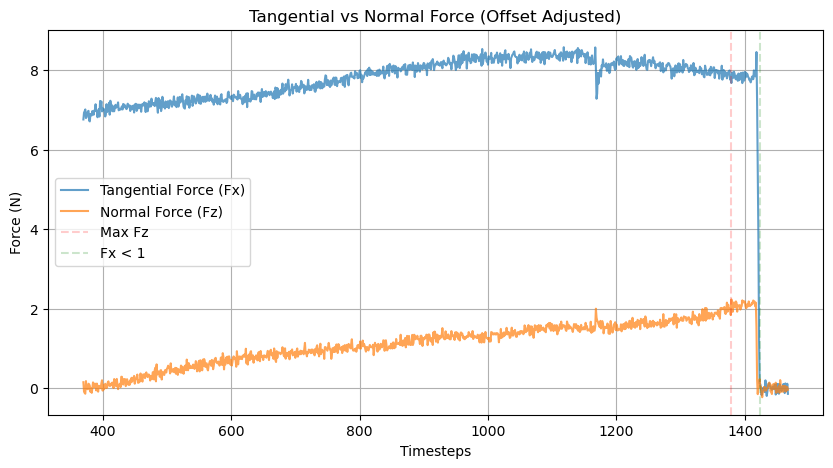

In [18]:
data = "../raw_data/Gripper Test Microspines Angles//Sediment_80_5N//log_202405281008.csv"
df = pd.read_csv(data)
test_1, end_1 = plot_forces(df, cut_1=370, cut_2=None, avg_end=1423, offset_position='end', offset_length=15)

<font size="6">Test 2: (partially worked / failed)</font>

Length from cut_1 to avg_end: 90
Average Fx in the averaging interval [773:863]: 5.1328505251142715
Average Fz in the averaging interval [773:863]: 0.1003750271267361
Maximum Fz in the plotting interval [773:900]: 0.34495035807291663 at timestep 853
Time step where Fx drops below 1: 863


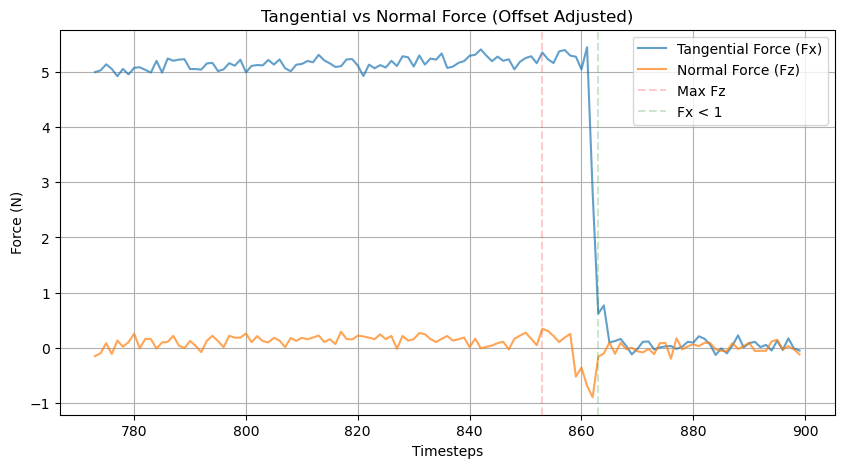

In [24]:
data = "../raw_data/Gripper Test Microspines Angles//Sediment_80_5N//log_202405281011.csv"
df = pd.read_csv(data)
test_2, end_2 = plot_forces(df, cut_1=773, cut_2=900, avg_end=863, offset_position='end', offset_length=15)

<font size="6">Test 3: (worked)</font>

Length from cut_1 to avg_end: 791
Average Fx in the averaging interval [1040:1831]: 5.526502820363388
Average Fz in the averaging interval [1040:1831]: 1.561504887750869
Maximum Fz in the plotting interval [1040:None]: 2.8720458984375 at timestep 1815
Time step where Fx drops below 1: 1831


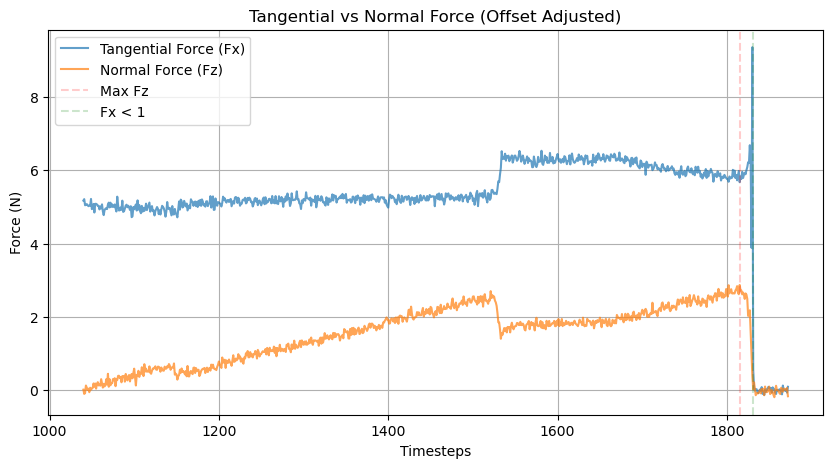

In [31]:
data = "../raw_data/Gripper Test Microspines Angles//Sediment_80_5N//log_202405281012.csv"
df = pd.read_csv(data)
test_3, end_3 = plot_forces(df, cut_1=1040, cut_2=None, avg_end=1831, offset_position='end', offset_length=15)

<font size="6">Test 4: (worked)</font>

Length from cut_1 to avg_end: 225
Average Fx in the averaging interval [750:975]: 5.650416747199165
Average Fz in the averaging interval [750:975]: 0.2669371202256945
Maximum Fz in the plotting interval [750:None]: 0.839599609375 at timestep 951
Time step where Fx drops below 1: 975


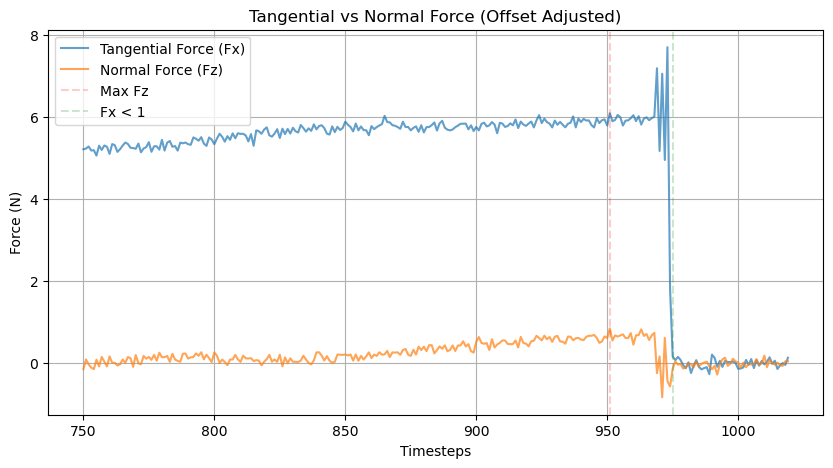

In [34]:
data = "../raw_data/Gripper Test Microspines Angles//Sediment_80_5N//log_202405281014.csv"
df = pd.read_csv(data)
test_4, end_4 = plot_forces(df, cut_1=750, cut_2=None, avg_end=975, offset_position='end', offset_length=15)

<font size="6">Test 5: (failed)</font>

Average Fx in the averaging interval [None:None]: 5.197180946384158
Average Fz in the averaging interval [None:None]: -1.6306026822044737
Maximum Fz in the plotting interval [None:None]: 0.19003499348958336 at timestep 1090
Time step where Fx drops below 1: 0


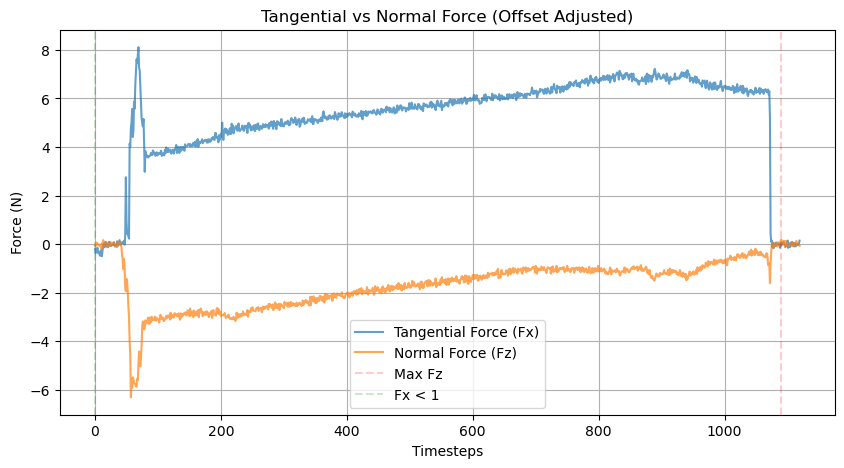

In [35]:
data = "../raw_data/Gripper Test Microspines Angles//Sediment_80_5N//log_202405281015.csv"
df = pd.read_csv(data)
test_5, end_5 = plot_forces(df, cut_1=None, cut_2=None, avg_end=None, offset_position='end', offset_length=15)

<font size="6">Test 6: (worked)</font>

Length from cut_1 to avg_end: 106
Average Fx in the averaging interval [1220:1326]: 5.14466601647671
Average Fz in the averaging interval [1220:1326]: 0.2487855539381879
Maximum Fz in the plotting interval [1220:1350]: 0.5868448893229167 at timestep 1302
Time step where Fx drops below 1: 1326


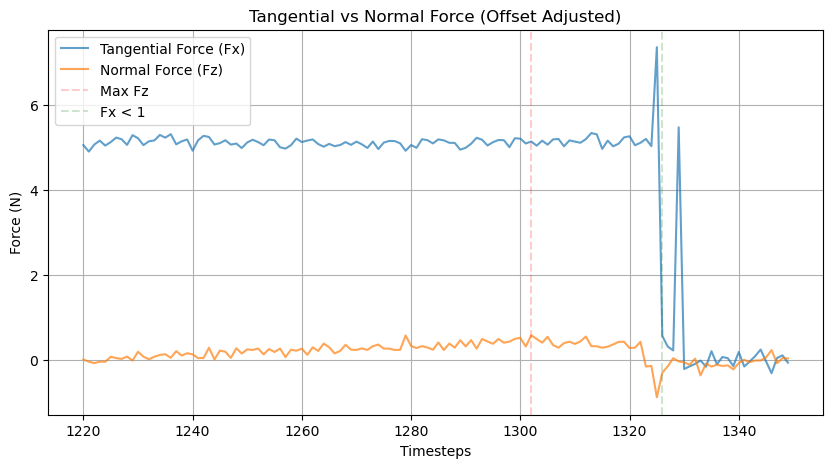

In [38]:
data = "../raw_data/Gripper Test Microspines Angles//Sediment_80_5N//log_202405281017.csv"
df = pd.read_csv(data)
test_6, end_6 = plot_forces(df, cut_1=1220, cut_2=1350, avg_end=1326, offset_position='beginning', offset_length=15)

<font size="6">Test 7: (failed)</font>

Average Fx in the averaging interval [None:None]: 4.950223353934658
Average Fz in the averaging interval [None:None]: -1.4631990668162187
Maximum Fz in the plotting interval [None:None]: 0.2620157877604167 at timestep 931
Time step where Fx drops below 1: 0


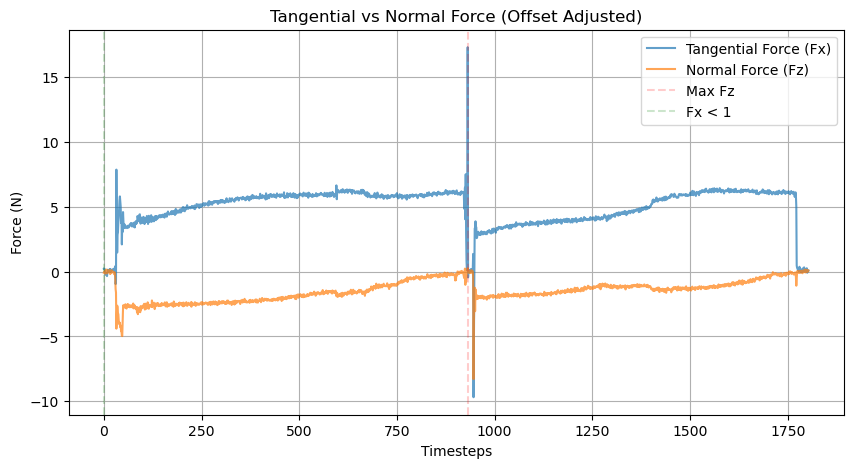

In [10]:
data = "../raw_data/Gripper Test Microspines Angles//Sediment_80_5N//log_202405281018.csv"
df = pd.read_csv(data)
test_7, end_7 = plot_forces(df, cut_1=None, cut_2=None, avg_end=None, offset_position='beginning', offset_length=15)

<font size="6">Test 8: (worked)</font>

Length from cut_1 to avg_end: 257
Average Fx in the averaging interval [679:936]: 6.179407626769267
Average Fz in the averaging interval [679:936]: 0.7404121290075794
Maximum Fz in the plotting interval [679:None]: 1.2862996419270833 at timestep 926
Time step where Fx drops below 1: 936


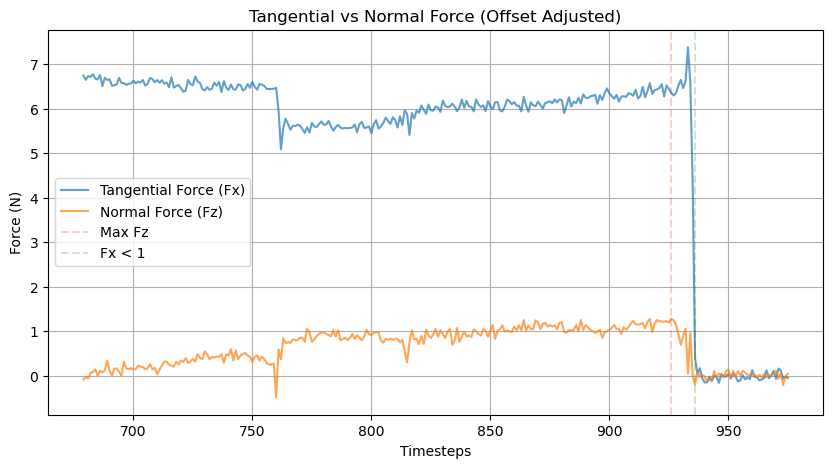

In [44]:
data = "../raw_data/Gripper Test Microspines Angles//Sediment_80_5N//log_202405281020.csv"
df = pd.read_csv(data)
test_8, end_8 = plot_forces(df, cut_1=679, cut_2=None, avg_end=936, offset_position='end', offset_length=15)

<font size="6">Test 9: (worked)</font>

Length from cut_1 to avg_end: 309
Average Fx in the averaging interval [800:1109]: 6.508113818184071
Average Fz in the averaging interval [800:1109]: 0.1494884503312096
Maximum Fz in the plotting interval [800:None]: 0.5690348307291667 at timestep 982
Time step where Fx drops below 1: 1109


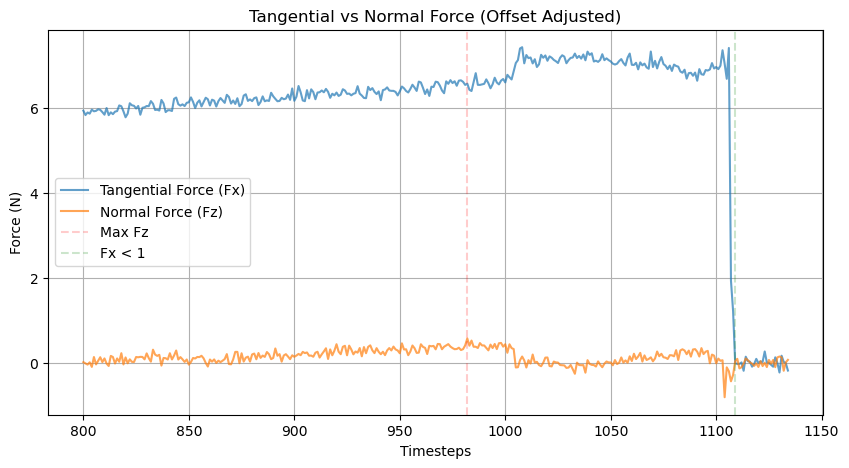

In [47]:
data = "../raw_data/Gripper Test Microspines Angles//Sediment_80_5N//log_202405281021.csv"
df = pd.read_csv(data)
test_9, end_9 = plot_forces(df, cut_1=800, cut_2=None, avg_end=1109, offset_position='end', offset_length=15)

<font size="6">Test 10: (failed)</font>

Average Fx in the averaging interval [None:None]: 4.592105501578795
Average Fz in the averaging interval [None:None]: -1.129123764284992
Maximum Fz in the plotting interval [None:None]: 0.1468221028645833 at timestep 679
Time step where Fx drops below 1: 0


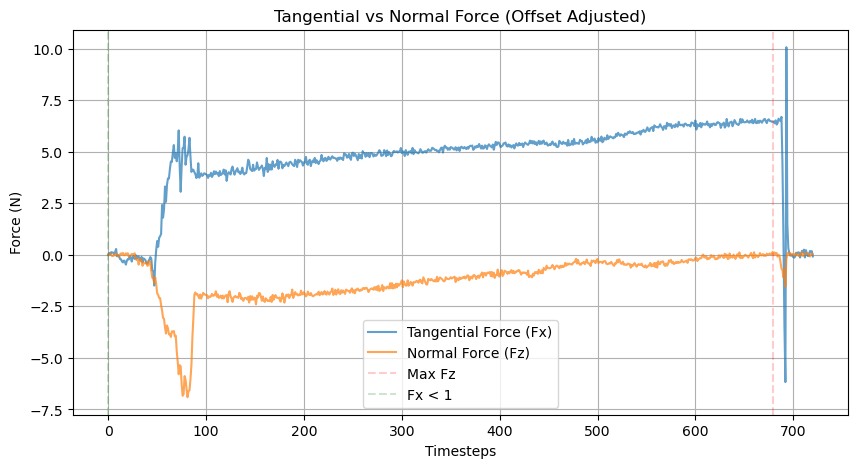

In [13]:
data = "../raw_data/Gripper Test Microspines Angles//Sediment_80_5N//log_202405281022.csv"
df = pd.read_csv(data)
test_10, end_10 = plot_forces(df, cut_1=None, cut_2=None, avg_end=None, offset_position='beginning', offset_length=15)

<font size="6">Test 11: (worked)</font>

Length from cut_1 to avg_end: 138
Average Fx in the averaging interval [800:938]: 5.423153166840042
Average Fz in the averaging interval [800:938]: 0.38636757670969213
Maximum Fz in the plotting interval [800:955]: 1.07061767578125 at timestep 915
Time step where Fx drops below 1: 938


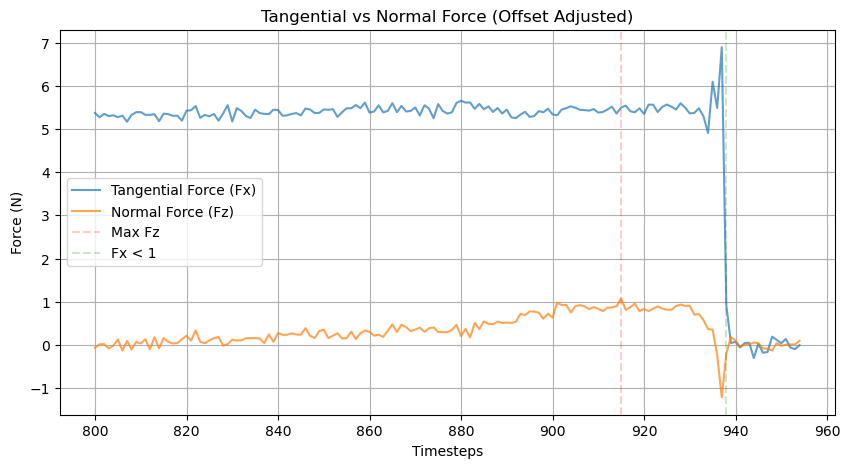

In [52]:
data = "../raw_data/Gripper Test Microspines Angles//Sediment_80_5N//log_202405281023.csv"
df = pd.read_csv(data)
test_11, end_11 = plot_forces(df, cut_1=800, cut_2=955, avg_end=938, offset_position='beginning', offset_length=15)

In [53]:
def plot_multiple_tests(tests, ends):
    # Find the maximum length among all datasets
    max_length = max([end for end in ends if end is not None])
    
    plt.figure(figsize=(15, 7))
    
    for i, (test, end) in enumerate(zip(tests, ends)):
        if end is not None:
            fz_series = test['Fz']
            fz_series_cut = fz_series[:end]
            if len(fz_series_cut) < max_length:
                padded_fz = np.pad(fz_series_cut.values, (0, max_length - len(fz_series_cut)), 'constant', constant_values=np.nan)
            else:
                padded_fz = fz_series_cut.values
            plt.plot(padded_fz, label=f'Dataset {i+1} Fz', alpha=0.6)
        
    plt.xlabel('Adjusted Timesteps')
    plt.ylabel('Normal Force (Fz) (N)')
    plt.legend()
    plt.title('Normal Force (Fz) of Multiple Datasets')
    plt.grid()
    plt.show()

In [57]:
def calculate_statistics(tests, ends):
    max_fz_values = []
    avg_fz_values = []
    avg_fx_values = []
    
    for test, end in zip(tests, ends):
        if end is not None:
            fz_series = test['Fz']
            fx_series = test['Fx']
            fz_series_cut = fz_series[:end]
            fx_series_cut = fx_series[:end]
            max_fz_values.append(fz_series_cut.max())
            avg_fz_values.append(fz_series_cut.mean())
            avg_fx_values.append(fx_series_cut.mean())
    
    average_max_fz = np.mean(max_fz_values)
    std_max_fz = np.std(max_fz_values)
    
    average_avg_fz = np.mean(avg_fz_values)
    std_avg_fz = np.std(avg_fz_values)
    
    average_avg_fx = np.mean(avg_fx_values)
    std_avg_fx = np.std(avg_fx_values)
    
    print(f"Average of maximum Fz forces: {average_max_fz}")
    print(f"Standard deviation of maximum Fz forces: {std_max_fz}")
    print(f"Average of average Fz forces: {average_avg_fz}")
    print(f"Standard deviation of average Fz forces: {std_avg_fz}")
    print(f"Average of average Fx forces: {average_avg_fx}")
    print(f"Standard deviation of average Fx forces: {std_avg_fx}")
    
    # Create a dictionary to store the statistics
    statistics_dict = {
        'Statistic': ['Average Max Fz', 'Std Max Fz', 'Average Avg Fz', 'Std Avg Fz', 'Average Avg Fx', 'Std Avg Fx'],
        'Value': [average_max_fz, std_max_fz, average_avg_fz, std_avg_fz, average_avg_fx, std_avg_fx]
    }
    
    # Convert the dictionary to a DataFrame
    statistics_df = pd.DataFrame(statistics_dict)
    
    # Save the statistics to a CSV file
    statistics_df.to_csv("../raw_data/Gripper Test Microspines Angles//80//Sediment_80_stats.csv", index=False)

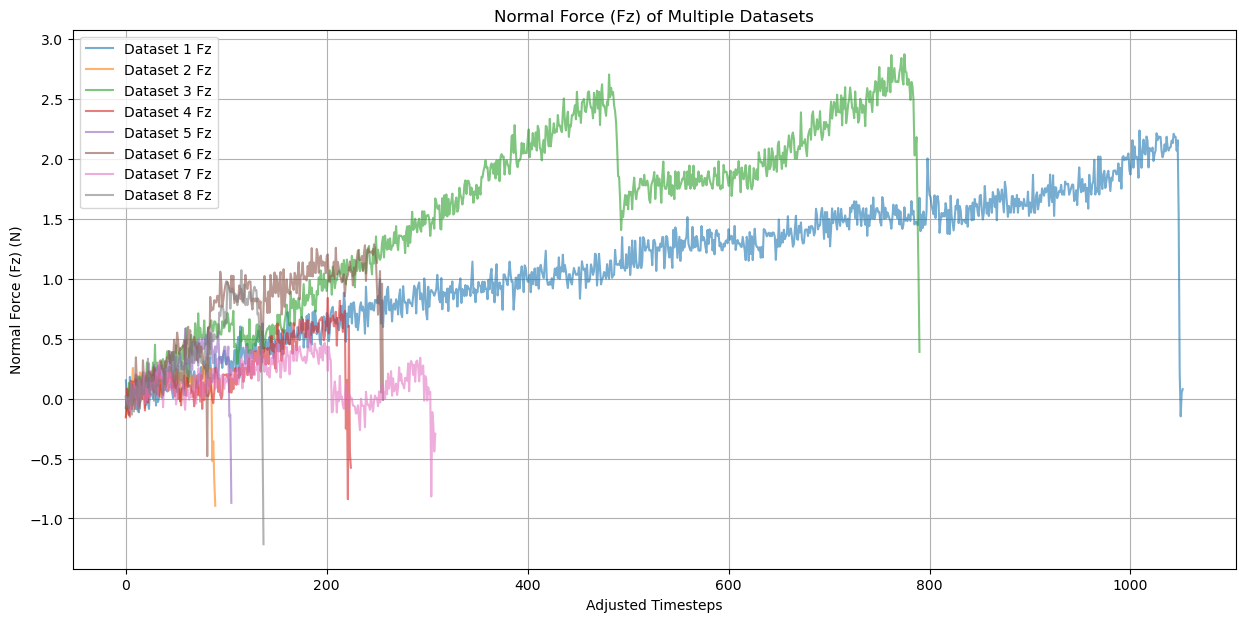

Average of maximum Fz forces: 1.2256856282552082
Standard deviation of maximum Fz forces: 0.8309037505107859
Average of average Fz forces: 0.5727289839726956
Standard deviation of average Fz forces: 0.4936480972195619
Average of average Fx forces: 5.920052895242785
Standard deviation of average Fx forces: 0.8385318961544147


In [60]:
tests = [test_1, test_2, test_3, test_4, test_6, test_8, test_9, test_11]
ends = [end_1, end_2, end_3, end_4, end_6, end_8, end_9, end_11]
plot_multiple_tests(tests, ends)
calculate_statistics(tests, ends)

In [61]:
def save_tests_to_csv_cut(tests, ends, file_prefix="../raw_data/Gripper Test Microspines Angles//80//Sediment_80"):
    # Save each test dataset to a separate CSV file, cutting at the end point
    for i, (test, end) in enumerate(zip(tests, ends)):
        test_cut = test.iloc[:end] if end is not None else test  # Cut the test data at the end point
        test_cut.to_csv(f'{file_prefix}_{i+1}.csv', index=False)

save_tests_to_csv_cut(tests, ends)